In [1]:
import os
import itertools
from collections import defaultdict

In [2]:
def load_documents(path="data"):
    
    docs = {}
    
    for i in range(1,5):
        with open(os.path.join(path,f"D{i}.txt"),"r") as f:
            docs[f"D{i}"] = f.read().strip()
            
    return docs

docs = load_documents()

print("Loaded Documents\n")

for name,text in docs.items():
    print(name,"->",text)

Loaded Documents

D1 -> apple ceo tim cook is spending some time in canada this week and yesterday he attended a hockey game and visited the eaton centre apple store in toronto cook today stopped by the offices of canadian ecommerce platform shopify where he spoke to the financial post about augmented reality apps and the homepod on the topic of the homepod cook said that apples deep integration between hardware and software will help to differentiate the smart speaker from competing products like amazons alexa and the google home competition makes all of us better and i welcome it cook said but if you are both trying to license something and compete with your licensees this is a difficult model and it remains to be seen if it can be successful or not cook also said a quality very immersive audio experience was one thing missing from the smart speaker market which apple is aiming to fix music deserves that kind of quality as opposed to some kind of squeaky sound he said the homepod whi

In [3]:
print("Document Statistics\n")

for name,text in docs.items():
    
    print("Document:",name)
    print("Length:",len(text))
    print("Words:",len(text.split()))
    print("Preview:",text[:60])
    print("-"*40)

Document Statistics

Document: D1
Length: 1749
Words: 303
Preview: apple ceo tim cook is spending some time in canada this week
----------------------------------------
Document: D2
Length: 1747
Words: 303
Preview: apple ceo tim cook is spending some time in canada this week
----------------------------------------
Document: D3
Length: 2132
Words: 380
Preview: as part of his one day tour of canada yesterday tim cook off
----------------------------------------
Document: D4
Length: 1435
Words: 255
Preview: president trump who warned as a candidate about the false so
----------------------------------------


In [4]:
def char_kgrams(text,k):
    
    grams=set()
    
    for i in range(len(text)-k+1):
        grams.add(text[i:i+k])
        
    return grams

In [5]:
def word_kgrams(text,k):
    
    words=text.split()
    
    grams=set()
    
    for i in range(len(words)-k+1):
        grams.add(tuple(words[i:i+k]))
        
    return grams

In [6]:
test="data mining course"

print("Character 2-grams")
print(char_kgrams(test,2))

print("\nCharacter 3-grams")
print(char_kgrams(test,3))

print("\nWord 2-grams")
print(word_kgrams(test,2))

Character 2-grams
{' m', 'mi', 'ng', ' c', 'g ', 'ni', 'co', 'ur', 'se', 'ta', 'da', 'at', 'rs', 'a ', 'ou', 'in'}

Character 3-grams
{' co', 'ata', 'ng ', 'g c', 'min', 'a m', 'cou', 'urs', 'nin', 'ing', 'ini', 'our', ' mi', 'ta ', 'dat', 'rse'}

Word 2-grams
{('mining', 'course'), ('data', 'mining')}


In [7]:
kgrams = {}

for name,text in docs.items():
    
    kgrams[name] = {
        "char2": char_kgrams(text,2),
        "char3": char_kgrams(text,3),
        "word2": word_kgrams(text,2)
    }

In [8]:
print("Number of k-grams in each document\n")

for doc in docs:
    
    print("Document:",doc)
    
    print("char2:",len(kgrams[doc]["char2"]))
    print("char3:",len(kgrams[doc]["char3"]))
    print("word2:",len(kgrams[doc]["word2"]))
    
    print("-"*30)

Number of k-grams in each document

Document: D1
char2: 263
char3: 765
word2: 279
------------------------------
Document: D2
char2: 262
char3: 762
word2: 278
------------------------------
Document: D3
char2: 269
char3: 828
word2: 337
------------------------------
Document: D4
char2: 255
char3: 698
word2: 232
------------------------------


In [9]:
for doc in docs:
    
    print("\nDocument:",doc)
    
    print("\nCharacter 2-grams:")
    print(sorted(list(kgrams[doc]["char2"]))[:20])
    
    print("\nCharacter 3-grams:")
    print(sorted(list(kgrams[doc]["char3"]))[:20])
    
    print("\nWord 2-grams:")
    print(list(kgrams[doc]["word2"])[:10])


Document: D1

Character 2-grams:
[' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h', ' i', ' k', ' l', ' m', ' n', ' o', ' p', ' q', ' r', ' s', ' t', ' u']

Character 3-grams:
[' a ', ' ab', ' ac', ' ad', ' ai', ' al', ' am', ' an', ' ap', ' ar', ' as', ' at', ' au', ' aw', ' be', ' bo', ' bu', ' by', ' ca', ' ce']

Word 2-grams:
[('with', 'your'), ('that', 'apples'), ('hockey', 'game'), ('read', 'over'), ('post', 'about'), ('with', 'the'), ('best', 'possible'), ('details', 'on'), ('topic', 'of'), ('his', 'interview')]

Document: D2

Character 2-grams:
[' a', ' b', ' c', ' d', ' e', ' f', ' g', ' h', ' i', ' k', ' l', ' m', ' n', ' o', ' p', ' q', ' r', ' s', ' t', ' u']

Character 3-grams:
[' a ', ' ab', ' ac', ' ad', ' ai', ' al', ' am', ' an', ' ap', ' ar', ' as', ' at', ' au', ' aw', ' be', ' bu', ' by', ' ca', ' ce', ' co']

Word 2-grams:
[('with', 'your'), ('that', 'apples'), ('hockey', 'game'), ('read', 'over'), ('post', 'about'), ('with', 'the'), ('best', 'possible'), ('details'

In [10]:
def jaccard(a,b):
    
    intersection = len(a & b)
    union = len(a | b)
    
    return intersection/union

In [11]:
A = {1,2,3,4}
B = {3,4,5}

print("Example sets")

print("A:",A)
print("B:",B)

print("\nIntersection:",A&B)
print("Union:",A|B)

print("\nJaccard similarity:",jaccard(A,B))

Example sets
A: {1, 2, 3, 4}
B: {3, 4, 5}

Intersection: {3, 4}
Union: {1, 2, 3, 4, 5}

Jaccard similarity: 0.4


In [12]:
pairs = list(itertools.combinations(docs.keys(),2))

print("Document pairs\n")

for p in pairs:
    print(p)

Document pairs

('D1', 'D2')
('D1', 'D3')
('D1', 'D4')
('D2', 'D3')
('D2', 'D4')
('D3', 'D4')


In [13]:
results = defaultdict(dict)

for gram_type in ["char2","char3","word2"]:
    
    print("\n============================")
    print("Gram Type:",gram_type)
    print("============================")
    
    for d1,d2 in pairs:
        
        sim = jaccard(
            kgrams[d1][gram_type],
            kgrams[d2][gram_type]
        )
        
        results[gram_type][(d1,d2)] = sim
        
        print(d1,"vs",d2,"=",round(sim,4))


Gram Type: char2
D1 vs D2 = 0.9811
D1 vs D3 = 0.8157
D1 vs D4 = 0.6444
D2 vs D3 = 0.8
D2 vs D4 = 0.6413
D3 vs D4 = 0.653

Gram Type: char3
D1 vs D2 = 0.978
D1 vs D3 = 0.5804
D1 vs D4 = 0.3051
D2 vs D3 = 0.568
D2 vs D4 = 0.3059
D3 vs D4 = 0.3121

Gram Type: word2
D1 vs D2 = 0.9408
D1 vs D3 = 0.1823
D1 vs D4 = 0.0302
D2 vs D3 = 0.1737
D2 vs D4 = 0.0303
D3 vs D4 = 0.0161


In [14]:
print("\nSummary Table\n")

for gram_type in results:
    
    print("\n",gram_type)
    
    for pair,val in results[gram_type].items():
        print(pair,"->",round(val,4))


Summary Table


 char2
('D1', 'D2') -> 0.9811
('D1', 'D3') -> 0.8157
('D1', 'D4') -> 0.6444
('D2', 'D3') -> 0.8
('D2', 'D4') -> 0.6413
('D3', 'D4') -> 0.653

 char3
('D1', 'D2') -> 0.978
('D1', 'D3') -> 0.5804
('D1', 'D4') -> 0.3051
('D2', 'D3') -> 0.568
('D2', 'D4') -> 0.3059
('D3', 'D4') -> 0.3121

 word2
('D1', 'D2') -> 0.9408
('D1', 'D3') -> 0.1823
('D1', 'D4') -> 0.0302
('D2', 'D3') -> 0.1737
('D2', 'D4') -> 0.0303
('D3', 'D4') -> 0.0161


In [15]:
all_char3=set()

for doc in kgrams:
    
    all_char3 |= kgrams[doc]["char3"]

print("Total unique 3-grams in corpus:",len(all_char3))

Total unique 3-grams in corpus: 1301


In [16]:
shingle_to_id={}

for i,shingle in enumerate(all_char3):
    shingle_to_id[shingle]=i

print("Total indexed shingles:",len(shingle_to_id))

print("\nExample mapping:")
for i,(k,v) in enumerate(shingle_to_id.items()):
    
    print(k,"->",v)
    
    if i==10:
        break

Total indexed shingles: 1301

Example mapping:
lif -> 0
s d -> 1
woo -> 2
rst -> 3
tol -> 4
l o -> 5
nse -> 6
ina -> 7
e s -> 8
be  -> 9
inv -> 10


In [17]:
doc_shingles={}

for doc in kgrams:
    
    ids=set()
    
    for g in kgrams[doc]["char3"]:
        ids.add(shingle_to_id[g])
        
    doc_shingles[doc]=ids

In [18]:
for doc in doc_shingles:
    
    print("\nDocument:",doc)
    
    print("Number of shingles:",len(doc_shingles[doc]))
    
    print("Example shingles:")
    print(list(doc_shingles[doc])[:15])


Document: D1
Number of shingles: 765
Example shingles:
[0, 1, 2, 5, 6, 7, 8, 9, 11, 14, 18, 22, 24, 25, 26]

Document: D2
Number of shingles: 762
Example shingles:
[0, 1, 2, 5, 6, 7, 8, 9, 11, 14, 18, 22, 24, 25, 26]

Document: D3
Number of shingles: 828
Example shingles:
[0, 1, 5, 6, 7, 8, 9, 17, 18, 23, 24, 25, 26, 27, 28]

Document: D4
Number of shingles: 698
Example shingles:
[3, 4, 7, 8, 9, 10, 11, 12, 13, 15, 16, 19, 20, 21, 24]


In [19]:
true_jaccard=jaccard(
    kgrams["D1"]["char3"],
    kgrams["D2"]["char3"]
)

print("True Jaccard similarity (D1 vs D2):",true_jaccard)

True Jaccard similarity (D1 vs D2): 0.977979274611399


In [20]:
import random

def generate_hash_functions(t,m):
    
    hash_funcs=[]
    
    for _ in range(t):
        
        a=random.randint(1,m-1)
        b=random.randint(0,m-1)
        
        hash_funcs.append((a,b))
        
    return hash_funcs

In [21]:
def compute_minhash_signature(shingles,hash_funcs,m):
    
    signature=[]
    
    for a,b in hash_funcs:
        
        min_val=float("inf")
        
        for shingle in shingles:
            
            h=(a*shingle + b) % m
            
            if h < min_val:
                min_val=h
        
        signature.append(min_val)
    
    return signature

In [22]:
def minhash_similarity(sig1,sig2):
    
    matches=0
    
    for i in range(len(sig1)):
        
        if sig1[i]==sig2[i]:
            matches+=1
            
    return matches/len(sig1)


Number of hash functions: 20
Approximate Jaccard: 1.0
True Jaccard: 0.977979274611399
Error: 0.022020725388601003
Time taken (seconds): 0.0040340423583984375

Number of hash functions: 60
Approximate Jaccard: 0.9833333333333333
True Jaccard: 0.977979274611399
Error: 0.005354058721934285
Time taken (seconds): 0.009937524795532227

Number of hash functions: 150
Approximate Jaccard: 0.9866666666666667
True Jaccard: 0.977979274611399
Error: 0.008687392055267695
Time taken (seconds): 0.022812366485595703

Number of hash functions: 300
Approximate Jaccard: 0.9866666666666667
True Jaccard: 0.977979274611399
Error: 0.008687392055267695
Time taken (seconds): 0.04514002799987793

Number of hash functions: 600
Approximate Jaccard: 0.98
True Jaccard: 0.977979274611399
Error: 0.0020207253886009857
Time taken (seconds): 0.08888101577758789

Number of hash functions: 800
Approximate Jaccard: 0.97375
True Jaccard: 0.977979274611399
Error: 0.004229274611398992
Time taken (seconds): 0.12229084968566895

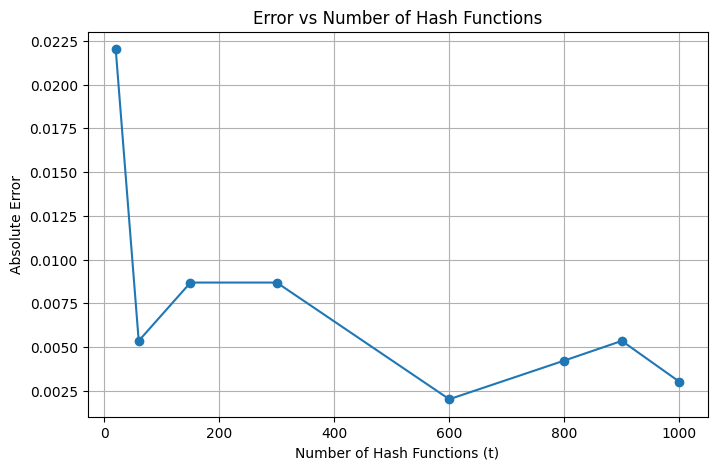

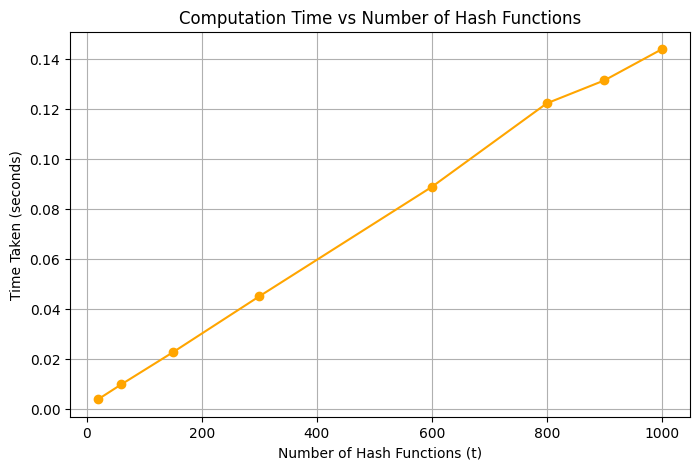

In [65]:
import matplotlib.pyplot as plt
import time

t_values = [20, 60, 150, 300, 600, 800,900,1000]
m = 100000
results = {}
errors = []
times = []

for t in t_values:
    print("\n=================================")
    print("Number of hash functions:", t)
    print("=================================")
    
    start_time = time.time()
    hash_funcs = generate_hash_functions(t, m)
    sig1 = compute_minhash_signature(doc_shingles["D1"], hash_funcs, m)
    sig2 = compute_minhash_signature(doc_shingles["D2"], hash_funcs, m)
    elapsed = time.time() - start_time
    
    approx = minhash_similarity(sig1, sig2)
    results[t] = approx
    error = abs(approx - true_jaccard)
    errors.append(error)
    times.append(elapsed)
    
    print("Approximate Jaccard:", approx)
    print("True Jaccard:", true_jaccard)
    print("Error:", error)
    print("Time taken (seconds):", elapsed)

# Plotting the error vs t
plt.figure(figsize=(8, 5))
plt.plot(t_values, errors, marker='o')
plt.xlabel("Number of Hash Functions (t)")
plt.ylabel("Absolute Error")
plt.title("Error vs Number of Hash Functions")
plt.grid(True)
plt.show()

# Plotting the time vs t
plt.figure(figsize=(8, 5))
plt.plot(t_values, times, marker='o', color='orange')
plt.xlabel("Number of Hash Functions (t)")
plt.ylabel("Time Taken (seconds)")
plt.title("Computation Time vs Number of Hash Functions")
plt.grid(True)
plt.show()

In [24]:
print("\nSummary of experiments\n")

for t,val in results.items():
    
    print("t =",t,
          "| Estimated Jaccard =",round(val,4),
          "| True =",round(true_jaccard,4))


Summary of experiments

t = 20 | Estimated Jaccard = 1.0 | True = 0.978
t = 60 | Estimated Jaccard = 0.9833 | True = 0.978
t = 150 | Estimated Jaccard = 0.9533 | True = 0.978
t = 300 | Estimated Jaccard = 0.9867 | True = 0.978
t = 600 | Estimated Jaccard = 0.97 | True = 0.978


In [25]:
print("Variance experiment with t = 100\n")

for i in range(5):
    
    hash_funcs=generate_hash_functions(100,100000)
    
    sig1=compute_minhash_signature(doc_shingles["D1"],hash_funcs,100000)
    sig2=compute_minhash_signature(doc_shingles["D2"],hash_funcs,100000)
    
    approx=minhash_similarity(sig1,sig2)
    
    print("Run",i+1,"->",approx)

Variance experiment with t = 100

Run 1 -> 0.98
Run 2 -> 0.98
Run 3 -> 0.99
Run 4 -> 0.96
Run 5 -> 0.93


In [26]:
t = 160
m = 100000

hash_funcs_160 = generate_hash_functions(t,m)

print("Number of hash functions:",len(hash_funcs_160))

Number of hash functions: 160


In [27]:
signatures={}

for doc in doc_shingles:
    
    sig = compute_minhash_signature(
        doc_shingles[doc],
        hash_funcs_160,
        m
    )
    
    signatures[doc]=sig

In [28]:
for doc in signatures:
    
    print("\nDocument:",doc)
    
    print("Signature length:",len(signatures[doc]))
    
    print("First 20 values:")
    print(signatures[doc][:20])


Document: D1
Signature length: 160
First 20 values:
[56, 25, 253, 76, 419, 69, 313, 272, 244, 30, 1, 30, 341, 107, 28, 22, 176, 25, 69, 79]

Document: D2
Signature length: 160
First 20 values:
[56, 25, 253, 76, 419, 69, 313, 272, 244, 30, 1, 30, 341, 107, 28, 22, 176, 25, 69, 79]

Document: D3
Signature length: 160
First 20 values:
[56, 29, 253, 76, 314, 69, 173, 12, 184, 70, 1, 54, 11, 10, 28, 9, 256, 25, 69, 174]

Document: D4
Signature length: 160
First 20 values:
[56, 125, 125, 131, 81, 69, 20, 12, 164, 347, 1, 6, 11, 107, 28, 9, 11, 25, 69, 79]


In [29]:
true_similarities={}

for d1,d2 in pairs:
    
    sim=jaccard(
        kgrams[d1]["char3"],
        kgrams[d2]["char3"]
    )
    
    true_similarities[(d1,d2)]=sim

print("True similarities\n")

for k,v in true_similarities.items():
    print(k,"->",round(v,4))

True similarities

('D1', 'D2') -> 0.978
('D1', 'D3') -> 0.5804
('D1', 'D4') -> 0.3051
('D2', 'D3') -> 0.568
('D2', 'D4') -> 0.3059
('D3', 'D4') -> 0.3121


In [30]:
def lsh_probability(s,r,b):
    
    return 1 - (1 - s**r)**b

In [67]:
candidates = [
    (1,160),
    (2,80),
    (4,40),
    (5,32),
    (8,20),
    (10,16),
    (16,10),
    (20,8),
]

print("Possible (r,b) combinations:\n")

for r,b in candidates:
    print("r =",r," b =",b," product =",r*b)

Possible (r,b) combinations:

r = 1  b = 160  product = 160
r = 2  b = 80  product = 160
r = 4  b = 40  product = 160
r = 5  b = 32  product = 160
r = 8  b = 20  product = 160
r = 10  b = 16  product = 160
r = 16  b = 10  product = 160
r = 20  b = 8  product = 160


In [71]:
print("LSH candidate probability for each document pair and (r, b):\n")
for r, b in candidates:
    print(f"\nFor r={r}, b={b}:")
    for pair, sim in true_similarities.items():
        prob = lsh_probability(sim, r, b)
        print(f"{pair}: similarity = {sim:.4f}, candidate probability = {prob:.4f}")

LSH candidate probability for each document pair and (r, b):


For r=1, b=160:
('D1', 'D2'): similarity = 0.9780, candidate probability = 1.0000
('D1', 'D3'): similarity = 0.5804, candidate probability = 1.0000
('D1', 'D4'): similarity = 0.3051, candidate probability = 1.0000
('D2', 'D3'): similarity = 0.5680, candidate probability = 1.0000
('D2', 'D4'): similarity = 0.3059, candidate probability = 1.0000
('D3', 'D4'): similarity = 0.3121, candidate probability = 1.0000

For r=2, b=80:
('D1', 'D2'): similarity = 0.9780, candidate probability = 1.0000
('D1', 'D3'): similarity = 0.5804, candidate probability = 1.0000
('D1', 'D4'): similarity = 0.3051, candidate probability = 0.9996
('D2', 'D3'): similarity = 0.5680, candidate probability = 1.0000
('D2', 'D4'): similarity = 0.3059, candidate probability = 0.9996
('D3', 'D4'): similarity = 0.3121, candidate probability = 0.9997

For r=4, b=40:
('D1', 'D2'): similarity = 0.9780, candidate probability = 1.0000
('D1', 'D3'): similarity = 0.58

In [83]:
import math

threshold = 0.7
total_hashes = 160
candidates = [(1, 160), (2, 80), (4, 40), (5, 32), (8, 20), (10, 16), 
              (16, 10), (20, 8), (32, 5), (40, 4), (80, 2), (160, 1)]

def get_inflection(b, r):
    return (1/r)**(1/b)

print(f"{'b':>5} {'r':>5} {'b*r':>5} {'s*':>10} {'|s*-τ|':>12}")
print("-" * 42)

best_diff = float('inf')
best_b, best_r, best_s = 0, 0, 0

for b, r in candidates:
    s_star = get_inflection(b, r)
    diff = abs(s_star - threshold)
    
    
    if diff < best_diff:
        best_diff = diff
        best_b, best_r, best_s = b, r, s_star

    print(f"{b:5d} {r:5d} {b*r:5d} {s_star:10.4f} {diff:10.4f}")

print(f"\nBest choice : b = {best_b} hashes/band,  r = {best_r} bands")
print(f"Inflection  : s* = {best_s:.4f}  (target τ = {threshold})")
print(f"S-curve     : f(s) = 1 - (1 - s^{best_b})^{best_r}")

    b     r   b*r         s*       |s*-τ|
------------------------------------------
    1   160   160     0.0063     0.6937
    2    80   160     0.1118     0.5882
    4    40   160     0.3976     0.3024
    5    32   160     0.5000     0.2000
    8    20   160     0.6877     0.0123
   10    16   160     0.7579     0.0579
   16    10   160     0.8660     0.1660
   20     8   160     0.9013     0.2013
   32     5   160     0.9509     0.2509
   40     4   160     0.9659     0.2659
   80     2   160     0.9914     0.2914
  160     1   160     1.0000     0.3000

Best choice : b = 8 hashes/band,  r = 20 bands
Inflection  : s* = 0.6877  (target τ = 0.7)
S-curve     : f(s) = 1 - (1 - s^8)^20


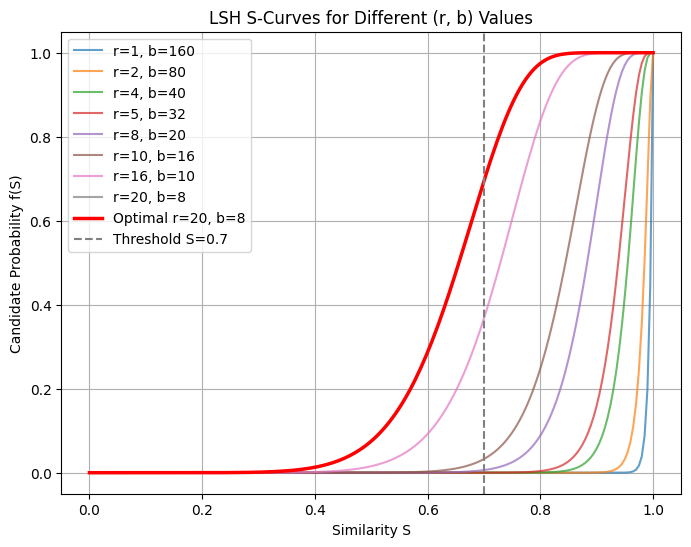

Optimal (r, b): r=20, b=8
At S=0.7, f(S)=0.6950 (closest to 0.7)


In [77]:
import numpy as np
import matplotlib.pyplot as plt

s_vals = np.linspace(0, 1, 200)
threshold = 0.7

best_rb = None
best_diff = float('inf')
best_curve = None

plt.figure(figsize=(8, 6))

for r, b in candidates:
    curve = [1 - (1 - s**b)**r for s in s_vals]
    f_at_thresh = 1 - (1 - threshold**b)**r
    diff = abs(f_at_thresh - 0.7)
    label = f"r={r}, b={b}"
    plt.plot(s_vals, curve, label=label, alpha=0.7)
    if diff < best_diff:
        best_diff = diff
        best_rb = (r, b)
        best_curve = curve

# Highlight the optimal curve
plt.plot(s_vals, best_curve, color='red', linewidth=2.5, label=f"Optimal r={best_rb[0]}, b={best_rb[1]}")

plt.axvline(threshold, color='gray', linestyle='--', label=f"Threshold S={threshold}")
plt.xlabel("Similarity S")
plt.ylabel("Candidate Probability f(S)")
plt.title("LSH S-Curves for Different (r, b) Values")
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal (r, b): r={best_rb[0]}, b={best_rb[1]}")
print(f"At S={threshold}, f(S)={1 - (1 - threshold**best_rb[1])**best_rb[0]:.4f} (closest to 0.7)")

In [32]:
threshold = 0.7

print("Probability at threshold s=0.7\n")

for r,b in candidates:
    
    prob = lsh_probability(threshold,r,b)
    
    print("r =",r,
          "b =",b,
          "-> probability =",round(prob,4))

Probability at threshold s=0.7

r = 2 b = 80 -> probability = 1.0
r = 4 b = 40 -> probability = 1.0
r = 5 b = 32 -> probability = 0.9972
r = 8 b = 20 -> probability = 0.695
r = 10 b = 16 -> probability = 0.3677
r = 16 b = 10 -> probability = 0.0327
r = 20 b = 8 -> probability = 0.0064


In [33]:
r = 8
b = 20

print("Chosen parameters")
print("r =",r)
print("b =",b)
print("r*b =",r*b)

Chosen parameters
r = 8
b = 20
r*b = 160


In [81]:
tau = 0.7
r = 8
b = 20

print(f"Probabilities for each document pair at τ={tau} with r={r}, b={b}:\n")
for pair, s in true_similarities.items():
    prob = lsh_probability(s, r, b)
    status = ">" if prob > 0.7 else "<="
    print(f"{pair}: similarity = {s:.4f}, prob = {prob:.4f}  --> prob {status} 0.7")

Probabilities for each document pair at τ=0.7 with r=8, b=20:

('D1', 'D2'): similarity = 0.9780, prob = 1.0000  --> prob > 0.7
('D1', 'D3'): similarity = 0.5804, prob = 0.2282  --> prob <= 0.7
('D1', 'D4'): similarity = 0.3051, prob = 0.0015  --> prob <= 0.7
('D2', 'D3'): similarity = 0.5680, prob = 0.1959  --> prob <= 0.7
('D2', 'D4'): similarity = 0.3059, prob = 0.0015  --> prob <= 0.7
('D3', 'D4'): similarity = 0.3121, prob = 0.0018  --> prob <= 0.7


True similar pairs (similarity >= 0.7): 1
Pairs: {('D1', 'D2')}



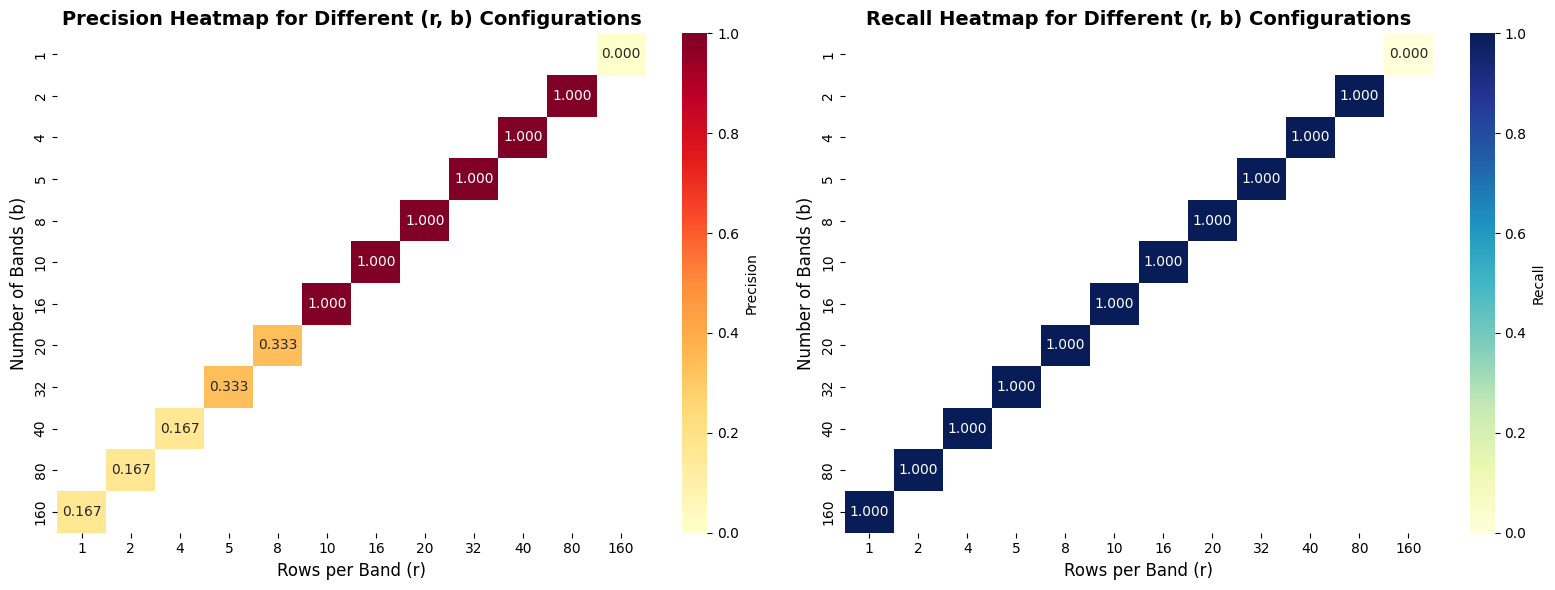

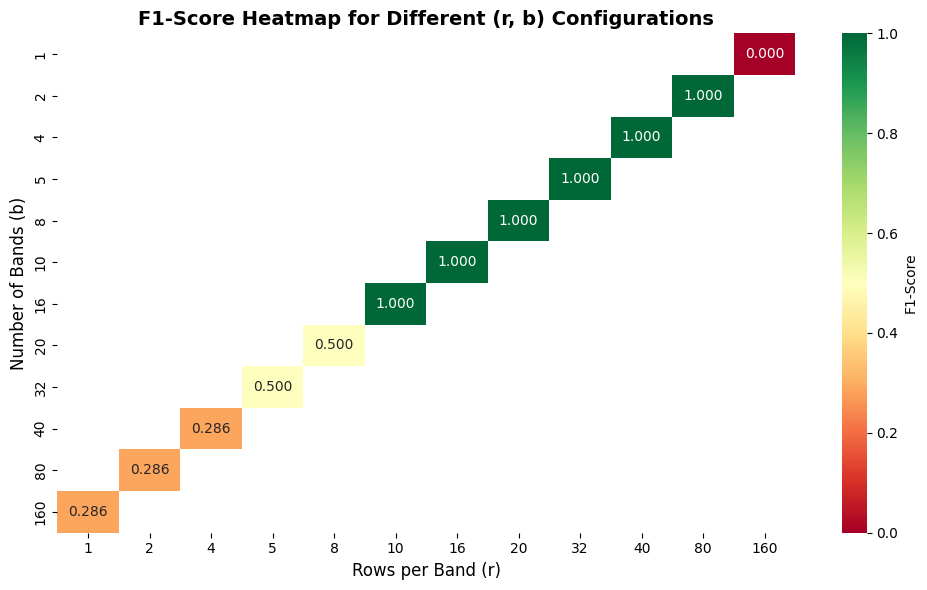


SUMMARY TABLE
  r   b  Precision  Recall  F1-Score
  1 160   0.166667     1.0  0.285714
  2  80   0.166667     1.0  0.285714
  4  40   0.166667     1.0  0.285714
  5  32   0.333333     1.0  0.500000
  8  20   0.333333     1.0  0.500000
 10  16   1.000000     1.0  1.000000
 16  10   1.000000     1.0  1.000000
 20   8   1.000000     1.0  1.000000
 32   5   1.000000     1.0  1.000000
 40   4   1.000000     1.0  1.000000
 80   2   1.000000     1.0  1.000000
160   1   0.000000     0.0  0.000000


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define threshold for considering pairs as similar
tau = 0.7

# Get true similar pairs (those with similarity >= tau)
true_similar_pairs = {pair for pair, sim in true_similarities.items() if sim >= tau}

print(f"True similar pairs (similarity >= {tau}): {len(true_similar_pairs)}")
print(f"Pairs: {true_similar_pairs}\n")

# Function to simulate LSH candidates using actual banding
def get_lsh_candidate_pairs(r, b):
    """Simulate LSH by banding the signatures and finding candidate pairs"""
    candidate_pairs = set()
    
    # For each band
    for band_idx in range(b):
        buckets = {}
        start = band_idx * r
        end = start + r
        
        # Hash each document's band
        for doc in signatures:
            band_sig = tuple(signatures[doc][start:end])
            
            if band_sig not in buckets:
                buckets[band_sig] = []
            buckets[band_sig].append(doc)
        
        # Find pairs in same bucket
        for bucket_docs in buckets.values():
            if len(bucket_docs) > 1:
                for pair in itertools.combinations(sorted(bucket_docs), 2):
                    candidate_pairs.add(pair)
    
    return candidate_pairs

# Calculate metrics for all candidates
results = []

for r, b in candidates:
    # Get candidate pairs using LSH
    candidate_pairs = get_lsh_candidate_pairs(r, b)
    
    # Calculate metrics
    tp = len(candidate_pairs & true_similar_pairs)  # True positives
    fp = len(candidate_pairs - true_similar_pairs)  # False positives
    fn = len(true_similar_pairs - candidate_pairs)  # False negatives
    
    # Calculate precision and recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    results.append({
        'r': r,
        'b': b,
        'Precision': precision,
        'Recall': recall
    })

# Create DataFrame
df_results = pd.DataFrame(results)

# Create pivot tables for heatmaps
pivot_precision = df_results.pivot(index='b', columns='r', values='Precision')
pivot_recall = df_results.pivot(index='b', columns='r', values='Recall')

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision heatmap
sns.heatmap(pivot_precision, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Precision'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Precision Heatmap for Different (r, b) Configurations', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rows per Band (r)', fontsize=12)
axes[0].set_ylabel('Number of Bands (b)', fontsize=12)

# Recall heatmap
sns.heatmap(pivot_recall, annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Recall'}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Recall Heatmap for Different (r, b) Configurations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rows per Band (r)', fontsize=12)
axes[1].set_ylabel('Number of Bands (b)', fontsize=12)

plt.tight_layout()
plt.show()

# Also create a combined F1-score heatmap
df_results['F1-Score'] = 2 * (df_results['Precision'] * df_results['Recall']) / \
                         (df_results['Precision'] + df_results['Recall'])
df_results['F1-Score'] = df_results['F1-Score'].fillna(0)

pivot_f1 = df_results.pivot(index='b', columns='r', values='F1-Score')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn', 
            cbar_kws={'label': 'F1-Score'}, vmin=0, vmax=1)
plt.title('F1-Score Heatmap for Different (r, b) Configurations', fontsize=14, fontweight='bold')
plt.xlabel('Rows per Band (r)', fontsize=12)
plt.ylabel('Number of Bands (b)', fontsize=12)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(df_results.to_string(index=False))

In [38]:
import pandas as pd

data = pd.read_csv(
    "movielens/u.data",
    sep="\t",
    names=["user","movie","rating","timestamp"]
)

print("Dataset shape:",data.shape)

data.head()

Dataset shape: (100000, 4)


,user,movie,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [39]:
user_movies={}

for user,movie in zip(data["user"],data["movie"]):
    
    if user not in user_movies:
        user_movies[user]=set()
        
    user_movies[user].add(movie)

print("Number of users:",len(user_movies))

Number of users: 943


In [40]:
sizes=[len(v) for v in user_movies.values()]

print("Average movies per user:",sum(sizes)/len(sizes))
print("Minimum movies:",min(sizes))
print("Maximum movies:",max(sizes))

Average movies per user: 106.04453870625663
Minimum movies: 20
Maximum movies: 737


In [41]:
def jaccard_users(u1,u2):
    
    a=user_movies[u1]
    b=user_movies[u2]
    
    return len(a & b)/len(a | b)

In [42]:
users=list(user_movies.keys())

print("Total users:",len(users))

user_pairs=list(itertools.combinations(users,2))

print("Total pairs:",len(user_pairs))

Total users: 943
Total pairs: 444153


In [93]:
exact_pairs=set()

print("Computing exact similarities...\n")

for u1,u2 in user_pairs:
    
    sim=jaccard_users(u1,u2)
    
    if sim >= 0.5:
        exact_pairs.add((u1,u2,sim))

print("pairs with similarity >= 0.5:")
for pair in exact_pairs:
    print("User1:",pair[0],"User2:",pair[1],"Similarity:",pair[2])
print("Number of pairs with similarity >= 0.5:",len(exact_pairs))

Computing exact similarities...

pairs with similarity >= 0.5:
User1: 800 User2: 879 Similarity: 0.5
User1: 197 User2: 826 Similarity: 0.512987012987013
User1: 328 User2: 788 Similarity: 0.6729559748427673
User1: 197 User2: 600 Similarity: 0.5
User1: 600 User2: 826 Similarity: 0.5454545454545454
User1: 451 User2: 489 Similarity: 0.5333333333333333
User1: 408 User2: 898 Similarity: 0.8387096774193549
User1: 489 User2: 587 Similarity: 0.6299212598425197
User1: 554 User2: 764 Similarity: 0.5170068027210885
User1: 674 User2: 879 Similarity: 0.5217391304347826
Number of pairs with similarity >= 0.5: 10


In [44]:
all_movies=set(data["movie"])

movie_to_id={}

for i,m in enumerate(all_movies):
    movie_to_id[m]=i

print("Total movies:",len(movie_to_id))

Total movies: 1682


In [45]:
user_movie_ids={}

for user in user_movies:
    
    ids=set()
    
    for m in user_movies[user]:
        ids.add(movie_to_id[m])
        
    user_movie_ids[user]=ids

In [46]:
def compute_user_signature(movie_ids,hash_funcs,m):
    
    sig=[]
    
    for a,b in hash_funcs:
        
        min_val=float("inf")
        
        for movie in movie_ids:
            
            h=(a*movie+b)%m
            
            if h<min_val:
                min_val=h
                
        sig.append(min_val)
        
    return sig

In [47]:
def run_minhash_experiment(t):
    
    m=100000
    
    hash_funcs=generate_hash_functions(t,m)
    
    signatures={}
    
    for user in user_movie_ids:
        
        signatures[user]=compute_user_signature(
            user_movie_ids[user],
            hash_funcs,
            m
        )
    
    approx_pairs=set()
    
    for u1,u2 in user_pairs:
        
        sim=minhash_similarity(
            signatures[u1],
            signatures[u2]
        )
        
        if sim>=0.5:
            approx_pairs.add((u1,u2))
    
    fp=len(approx_pairs - exact_pairs)
    
    fn=len(exact_pairs - approx_pairs)
    
    return fp,fn

In [95]:
t_values=[50,100,200]

results={}

for t in t_values:
    
    fps=[]
    fns=[]
    
    print("\nRunning experiment for t =",t)
    
    for i in range(5):
        
        fp,fn=run_minhash_experiment(t)
        
        fps.append(fp)
        fns.append(fn)
        
        print("Run",i+1,"FP:",fp,"FN:",fn)
    
    results[t]=(
        sum(fps)/5,
        sum(fns)/5
    )

    print(f"Average FP for t={t}: {results[t][0]}")
    print(f"Average FN for t={t}: {results[t][1]}")


Running experiment for t = 50
Run 1 FP: 142 FN: 10
Run 2 FP: 86 FN: 10
Run 3 FP: 115 FN: 10
Run 4 FP: 199 FN: 10
Run 5 FP: 159 FN: 10
Average FP for t=50: 140.2
Average FN for t=50: 10.0

Running experiment for t = 100
Run 1 FP: 23 FN: 10
Run 2 FP: 89 FN: 10
Run 3 FP: 37 FN: 10
Run 4 FP: 22 FN: 10
Run 5 FP: 32 FN: 10
Average FP for t=100: 40.6
Average FN for t=100: 10.0

Running experiment for t = 200
Run 1 FP: 14 FN: 10
Run 2 FP: 10 FN: 10
Run 3 FP: 11 FN: 10
Run 4 FP: 27 FN: 10
Run 5 FP: 17 FN: 10
Average FP for t=200: 15.8
Average FN for t=200: 10.0


In [49]:
def band_hash(band):
    
    return hash(tuple(band))

In [50]:
def lsh_candidates(signatures, r, b):
    
    buckets = {}
    
    for band in range(b):
        
        buckets.clear()
        
        start = band * r
        end = start + r
        
        for user in signatures:
            
            band_sig = signatures[user][start:end]
            
            h = band_hash(band_sig)
            
            if h not in buckets:
                buckets[h] = []
            
            buckets[h].append(user)
        
        for bucket in buckets.values():
            
            if len(bucket) > 1:
                
                for pair in itertools.combinations(bucket,2):
                    yield pair

In [101]:
def run_lsh_experiment(t,r,b,threshold=0.6):
    
    m=100000
    
    hash_funcs=generate_hash_functions(t,m)
    
    signatures={}
    
    for user in user_movie_ids:
        
        signatures[user]=compute_user_signature(
            user_movie_ids[user],
            hash_funcs,
            m
        )
    
    candidate_pairs=set(lsh_candidates(signatures,r,b))
    
    predicted=set()
    
    for u1,u2 in candidate_pairs:
        
        sim=jaccard_users(u1,u2)
        
        if sim >= threshold:
            predicted.add((u1,u2))
    
    true_pairs=set()
    
    for u1,u2 in user_pairs:
        
        sim=jaccard_users(u1,u2)
        
        if sim >= threshold:
            true_pairs.add((u1,u2))
    
    fp=len(predicted - true_pairs)
    fn=len(true_pairs - predicted)
    
    return fp,fn

In [52]:
configs = [
    (50,5,10),
    (100,5,20),
    (200,5,40),
    (200,10,20)
]

configs

[(50, 5, 10), (100, 5, 20), (200, 5, 40), (200, 10, 20)]

In [ ]:
results_lsh={}

for t,r,b in configs:
    
    fps=[]
    fns=[]
    
    print("\nConfiguration")
    print("t =",t,"r =",r,"b =",b)
    
    for i in range(5):
        
        fp,fn = run_lsh_experiment(t,r,b,threshold=0.6)
        
        fps.append(fp)
        fns.append(fn)
        
        print("Run",i+1,"FP:",fp,"FN:",fn)
    
    results_lsh[(t,r,b)] = (
        sum(fps)/5,
        sum(fns)/5
    )
    
    print(f"Average FP for t={t}, r={r}, b={b}: {results_lsh[(t,r,b)][0]}")
    print(f"Average FN for t={t}, r={r}, b={b}: {results_lsh[(t,r,b)][1]}")


Configuration
t = 50 r = 5 b = 10
Run 1 FP: 0 FN: 2
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 1
Run 5 FP: 0 FN: 2
Average FP for t=50, r=5, b=10: 0.0
Average FN for t=50, r=5, b=10: 1.0

Configuration
t = 100 r = 5 b = 20
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 1
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 1
Run 5 FP: 0 FN: 0
Average FP for t=100, r=5, b=20: 0.0
Average FN for t=100, r=5, b=20: 0.4

Configuration
t = 200 r = 5 b = 40
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0
Average FP for t=200, r=5, b=40: 0.0
Average FN for t=200, r=5, b=40: 0.0

Configuration
t = 200 r = 10 b = 20
Run 1 FP: 0 FN: 2
Run 2 FP: 0 FN: 1
Run 3 FP: 0 FN: 2
Run 4 FP: 0 FN: 2
Run 5 FP: 0 FN: 2
Average FP for t=200, r=10, b=20: 0.0
Average FN for t=200, r=10, b=20: 1.8


In [97]:
print("\nAverage False Positives and False Negatives\n")

for config,(fp,fn) in results_lsh.items():
    
    t,r,b=config
    
    print(
        "t=",t,
        "r=",r,
        "b=",b,
        "| Avg FP:",round(fp,2),
        "| Avg FN:",round(fn,2)
    )


Average False Positives and False Negatives

t= 50 r= 5 b= 10 | Avg FP: 0.0 | Avg FN: 1.0
t= 100 r= 5 b= 20 | Avg FP: 0.0 | Avg FN: 0.4
t= 200 r= 5 b= 40 | Avg FP: 0.0 | Avg FN: 0.0
t= 200 r= 10 b= 20 | Avg FP: 0.0 | Avg FN: 1.8


In [102]:
results_lsh={}

for t,r,b in configs:
    
    fps=[]
    fns=[]
    
    print("\nConfiguration")
    print("t =",t,"r =",r,"b =",b)
    
    for i in range(5):
        
        fp,fn = run_lsh_experiment(t,r,b,threshold=0.8)
        
        fps.append(fp)
        fns.append(fn)
        
        print("Run",i+1,"FP:",fp,"FN:",fn)
    
    results_lsh[(t,r,b)] = (
        sum(fps)/5,
        sum(fns)/5
    )
    
    print(f"Average FP for t={t}, r={r}, b={b}: {results_lsh[(t,r,b)][0]}")
    print(f"Average FN for t={t}, r={r}, b={b}: {results_lsh[(t,r,b)][1]}")


Configuration
t = 50 r = 5 b = 10
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0
Average FP for t=50, r=5, b=10: 0.0
Average FN for t=50, r=5, b=10: 0.0

Configuration
t = 100 r = 5 b = 20
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0
Average FP for t=100, r=5, b=20: 0.0
Average FN for t=100, r=5, b=20: 0.0

Configuration
t = 200 r = 5 b = 40
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0
Average FP for t=200, r=5, b=40: 0.0
Average FN for t=200, r=5, b=40: 0.0

Configuration
t = 200 r = 10 b = 20
Run 1 FP: 0 FN: 0
Run 2 FP: 0 FN: 0
Run 3 FP: 0 FN: 0
Run 4 FP: 0 FN: 0
Run 5 FP: 0 FN: 0
Average FP for t=200, r=10, b=20: 0.0
Average FN for t=200, r=10, b=20: 0.0


In [103]:
print("\nAverage False Positives and False Negatives\n")

for config,(fp,fn) in results_lsh.items():
    
    t,r,b=config
    
    print(
        "t=",t,
        "r=",r,
        "b=",b,
        "| Avg FP:",round(fp,2),
        "| Avg FN:",round(fn,2)
    )


Average False Positives and False Negatives

t= 50 r= 5 b= 10 | Avg FP: 0.0 | Avg FN: 0.0
t= 100 r= 5 b= 20 | Avg FP: 0.0 | Avg FN: 0.0
t= 200 r= 5 b= 40 | Avg FP: 0.0 | Avg FN: 0.0
t= 200 r= 10 b= 20 | Avg FP: 0.0 | Avg FN: 0.0


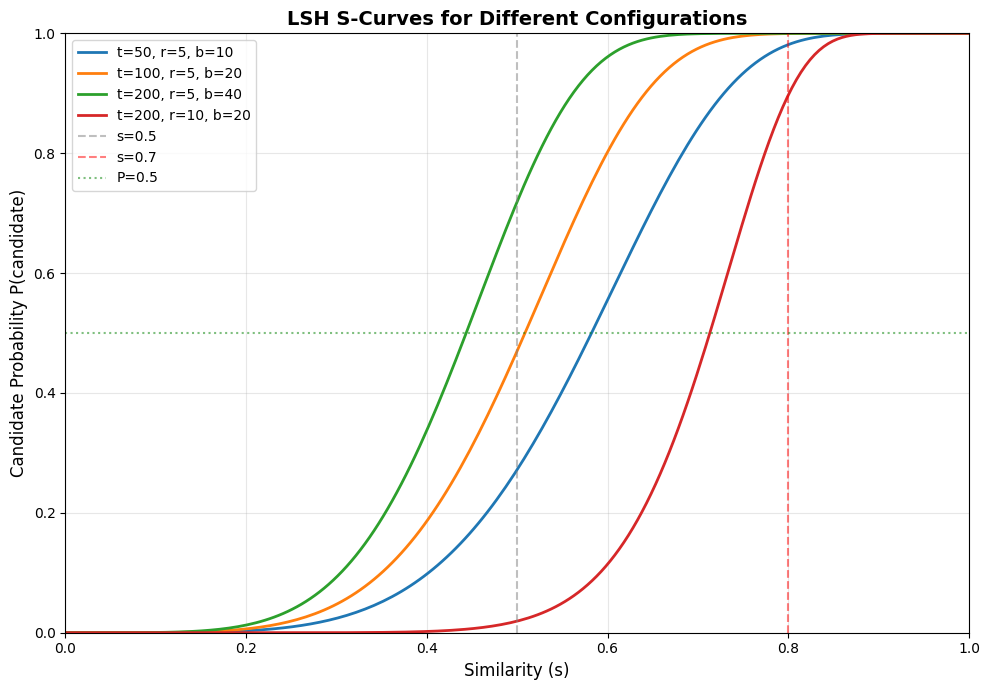


Candidate Probabilities at Different Similarity Thresholds
    t     r     b |   P(s=0.5)   P(s=0.6)   P(s=0.7)   P(s=0.8)
----------------------------------------------------------------------
   50     5    10 |     0.2720     0.5549     0.8412     0.9811
  100     5    20 |     0.4701     0.8019     0.9748     0.9996
  200     5    40 |     0.7192     0.9608     0.9994     1.0000
  200    10    20 |     0.0194     0.1142     0.4362     0.8969

Average False Positives and False Negatives (from experiments)
    t     r     b |     Avg FP     Avg FN
----------------------------------------------------------------------
   50     5    10 |       0.00       0.00
  100     5    20 |       0.00       0.00
  200     5    40 |       0.00       0.00
  200    10    20 |       0.00       0.00


In [105]:
import numpy as np
import matplotlib.pyplot as plt

s_vals = np.linspace(0, 1, 200)

plt.figure(figsize=(10, 7))

for t, r, b in configs:
    curve = [1 - (1 - s**r)**b for s in s_vals]
    
    plt.plot(s_vals, curve, linewidth=2, label=f't={t}, r={r}, b={b}')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='s=0.5')
plt.axvline(0.8, color='red', linestyle='--', alpha=0.5, label='s=0.7')

plt.axhline(0.5, color='green', linestyle=':', alpha=0.5, label='P=0.5')

plt.xlabel('Similarity (s)', fontsize=12)
plt.ylabel('Candidate Probability P(candidate)', fontsize=12)
plt.title('LSH S-Curves for Different Configurations', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Candidate Probabilities at Different Similarity Thresholds")
print("="*70)
print(f"{'t':>5} {'r':>5} {'b':>5} | {'P(s=0.5)':>10} {'P(s=0.6)':>10} {'P(s=0.7)':>10} {'P(s=0.8)':>10}")
print("-"*70)

for t, r, b in configs:
    p_05 = 1 - (1 - 0.5**r)**b
    p_06 = 1 - (1 - 0.6**r)**b
    p_07 = 1 - (1 - 0.7**r)**b
    p_08 = 1 - (1 - 0.8**r)**b
    
    print(f"{t:5d} {r:5d} {b:5d} | {p_05:10.4f} {p_06:10.4f} {p_07:10.4f} {p_08:10.4f}")

print("\n" + "="*70)
print("Average False Positives and False Negatives (from experiments)")
print("="*70)
print(f"{'t':>5} {'r':>5} {'b':>5} | {'Avg FP':>10} {'Avg FN':>10}")
print("-"*70)

for config, (fp, fn) in results_lsh.items():
    t, r, b = config
    print(f"{t:5d} {r:5d} {b:5d} | {fp:10.2f} {fn:10.2f}")